In [1]:
import tensorflow as tf
import keras
import numpy as np
import sys
import matplotlib.pyplot as plt

sys.path.append("../")

In [2]:
DATA_DIR = "../mu3e_trigger_data"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_pixel_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_mppc_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_mppc_spacetime.npy"


bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)
sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)




input_seq_len = bg_pixel_spacetime.shape[1]
input_dim = bg_pixel_spacetime.shape[2]  # Exclude timestamp

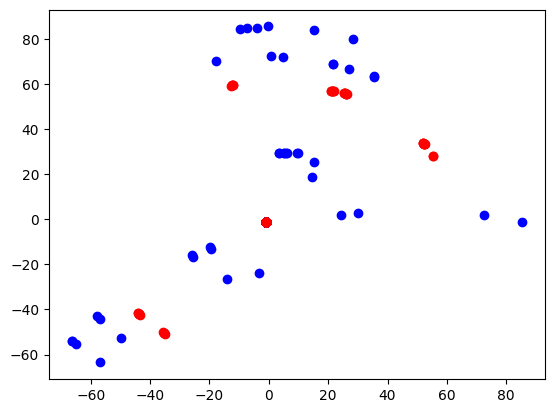

In [3]:
plt.scatter(bg_pixel_spacetime[:1, :, 0], bg_pixel_spacetime[:1, :, 1], color = "blue")
plt.scatter(bg_mppc_spacetime[:1, :, 0], bg_mppc_spacetime[:1, :, 1], color = "red")
plt.show()

In [4]:
pixel_input = keras.Input(shape=(input_seq_len, input_dim), name="pixel_input")
mppc_input = keras.Input(shape=(input_seq_len, input_dim), name="mppc_input")

In [ ]:
from src.model.components import (
    point_transformer,
    SelfAttentionStack,
    MultiHeadAttentionBlock,
    MLP,
    GenerateMask,
    PoolingAttentionBlock,
    MultiHeadAttentionStack,
)

feature_dim = 8
latent_dim = 16 // 2
num_heads = 8

pixel_mask = GenerateMask(-1, name="pixel_mask")(pixel_input)
mppc_mask = GenerateMask(-1, name="mppc_mask")(mppc_input)

pixel_embedding = MLP(output_dim=feature_dim, name="pixel_embedding")(pixel_input)

mppc_embedding = MLP(output_dim=feature_dim, name="mppc_embedding")(mppc_input)

pixel_attention = SelfAttentionStack(
    num_heads=num_heads,
    key_dim=feature_dim,
    stack_size=3,
    name="pixel_attention",
)(pixel_embedding, pixel_mask)

mppc_attention = SelfAttentionStack(
    num_heads=num_heads,
    key_dim=feature_dim,
    stack_size=3,
    name="mppc_attention",
)(mppc_embedding, mppc_mask)

mppc_attend_pixel = MultiHeadAttentionStack(
    num_heads=num_heads,
    key_dim=feature_dim,
    stack_size=1,
    name="mppc_attend_pixel",
)(
    query=mppc_attention,
    value=pixel_attention,
    query_mask=mppc_mask,
    value_mask=pixel_mask,
    key_mask=pixel_mask,
)

pixel_attend_mppc = MultiHeadAttentionStack(
    num_heads=num_heads,
    key_dim=feature_dim,
    stack_size=1,
    name="pixel_attend_mppc",
)(
    query=pixel_attention,
    value=mppc_attention,
    query_mask=pixel_mask,
    value_mask=mppc_mask,
    key_mask=mppc_mask,
)

pixel_attentions_pool = PoolingAttentionBlock(
    name="pixel_attentions_pool",
    key_dim=feature_dim,
    num_seeds=latent_dim,
    num_heads=num_heads,
)(pixel_attention, pixel_mask)

pixel_flattened_pool = keras.layers.Flatten(name="pixel_flattened_pool")(
    pixel_attentions_pool
)

mppc_attentions_pool = PoolingAttentionBlock(
    name="mppc_attentions_pool",
    key_dim=feature_dim,
    num_seeds=latent_dim,
    num_heads=num_heads,
)(mppc_attention, mppc_mask)

mppc_flattened_pool = keras.layers.Flatten(name="mppc_flattened_pool")(
    mppc_attentions_pool
)

latent_space = keras.layers.Concatenate(name="latent_space")(
    [
        pixel_flattened_pool,
        mppc_flattened_pool,
    ]
)

output = MLP(num_layers=5, output_dim=1, activation="sigmoid", name="output")(
    latent_space
)

model = keras.Model(
    inputs=[pixel_input, mppc_input],
    outputs=output,
    name="ClassificationModel",
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

In [6]:
model.summary()

Model: "ClassificationModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mppc_input          │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_input         │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_mask           │ (None, 128, 1)    │          0 │ mppc_input[0][0]  │
│ (GenerateMask)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_embedding     │ (None, 128, 8)    │        234 │ pixel_input[0][0] │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_mask          │ (None, 128, 1)    │          0 │ pixel_input[0][0] │
│ (GenerateMask)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_embedding      │ (None, 128, 8)    │        234 │ mppc_input[0][0]  │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_attention     │ (None, 128, 8)    │      7,680 │ pixel_embedding[… │
│ (SelfAttentionStac… │                   │            │ pixel_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_attention      │ (None, 128, 8)    │      7,680 │ mppc_embedding[0… │
│ (SelfAttentionStac… │                   │            │ mppc_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_attend_mppc   │ (None, 128, 8)    │      2,560 │ mppc_mask[0][0],  │
│ (MultiHeadAttentio… │                   │            │ pixel_attention[… │
│                     │                   │            │ pixel_mask[0][0], │
│                     │                   │            │ mppc_attention[0… │
│                     │                   │            │ mppc_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_attend_pixel   │ (None, 128, 8)    │      2,560 │ pixel_mask[0][0], │
│ (MultiHeadAttentio… │                   │            │ mppc_attention[0… │
│                     │                   │            │ mppc_mask[0][0],  │
│                     │                   │            │ pixel_attention[… │
│                     │                   │            │ pixel_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_attentions_p… │ (None, 8, 8)      │      2,624 │ pixel_attend_mpp… │
│ (PoolingAttentionB… │                   │            │ pixel_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_attentions_po… │ (None, 8, 8)      │      2,624 │ mppc_attend_pixe… │
│ (PoolingAttentionB… │                   │            │ mppc_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_flattened_po… │ (None, 64)        │          0 │ pixel_attentions… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_flattened_pool │ (None, 64)        │          0 │ mppc_attentions_… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_space        │ (None, 128)       │          0 │ pixel_flattened_

 Total params: 33,727 (131.75 KB)

 Trainable params: 33,727 (131.75 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from sklearn.model_selection import train_test_split

(
    X_pixel_train,
    X_pixel_test,
    X_mppc_train,
    X_mppc_test,
    y_train,
    y_test,
) = train_test_split(
    np.concatenate([bg_pixel_spacetime[:, :, :], sig_pixel_spacetime[:, :, :]], axis=0),
    np.concatenate([bg_mppc_spacetime[:, :, :], sig_mppc_spacetime[:, :, :]], axis=0),
    np.concatenate(
        [np.zeros(len(bg_pixel_spacetime)), np.ones(len(sig_pixel_spacetime))]
    ),
    test_size=0.2,
    random_state=42,
    shuffle=True,
)


In [ ]:
model.fit(
    x=[X_pixel_train, X_mppc_train],
    y=y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        )
    ],
    class_weight = {label: np.mean(y_train == label) for label in np.unique(y_train)}
)

Epoch 1/100


/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'ffn_layer' (of type Sequential) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'mppc_attentions_pool' (of type PoolingAttentionBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


2777/2777 ━━━━━━━━━━━━━━━━━━━━ 586s 209ms/step - binary_accuracy: 0.5595 - loss: 0.3253 - val_binary_accuracy: 0.5600 - val_loss: 0.6509
Epoch 2/100
2777/2777 ━━━━━━━━━━━━━━━━━━━━ 596s 215ms/step - binary_accuracy: 0.5701 - loss: 0.3200 - val_binary_accuracy: 0.5897 - val_loss: 0.6584
Epoch 3/100
2777/2777 ━━━━━━━━━━━━━━━━━━━━ 631s 227ms/step - binary_accuracy: 0.5982 - loss: 0.3179 - val_binary_accuracy: 0.6171 - val_loss: 0.6449
Epoch 4/100
2777/2777 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - binary_accuracy: 0.6003 - loss: 0.3189

In [ ]:
hahatest_seq_length = (X_pixel_test != -1).all(axis=-1).sum(axis=-1) + (X_mppc_test != -1).all(
    axis=-1
).sum(axis=-1)
test_mppc_length = (X_mppc_test != -1).all(axis=-1).sum(axis=-1)
test_pixel_length = (X_pixel_test != -1).all(axis=-1).sum(axis=-1)
train_mppc_length = (X_mppc_train != -1).all(axis=-1).sum(axis=-1)
train_pixel_length = (X_pixel_train != -1).all(axis=-1).sum(axis=-1)

In [ ]:
mppc_lenght_input = keras.Input(shape=(1,), name="mppc_length_input")
pixel_length_input = keras.Input(shape=(1,), name="pixel_length_input")

input = keras.layers.Concatenate(name="input")(
    [
        mppc_lenght_input,
        pixel_length_input,
    ]
)
encoder = MLP(
    num_layers=3,
    output_dim=10,
    name="encoder",
    activation="relu",
)(input)
decoder = MLP(
    num_layers=3,
    output_dim=1,
    name="decoder",
    activation="sigmoid",
)(encoder)
seq_length_mlp = keras.Model(
    inputs=[mppc_lenght_input, pixel_length_input],
    outputs=decoder,
    name="SeqLengthMLP",
)

In [ ]:
seq_length_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy()],
)
seq_length_mlp.summary()

In [ ]:
seq_length_mlp.fit(
    x=[train_mppc_length, train_pixel_length],
    y=y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True
        )
    ],
    class_weight={label: np.sum(y_train == label) / len(y_train) for label in np.unique(y_train) if label in [0, 1]}
)

In [ ]:
test_predictions = model.predict([X_pixel_test, X_mppc_test])
test_seq_length = seq_length_mlp.predict([test_mppc_length, test_pixel_length])

from sklearn.metrics import confusion_matrix, roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, test_predictions)
fpr_seq_length, tpr_seq_length, thresholds_seq_length = roc_curve(y_test, test_seq_length)
roc_auc_seq_length = auc(fpr_seq_length, tpr_seq_length)
roc_auc = auc(fpr, tpr)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", label="ROC curve (area = {:.2f})".format(roc_auc))
plt.plot(
    fpr_seq_length,
    tpr_seq_length,
    color="green",
    label="MLP trained on number of hits of MPPC and Pixels (area = {:.2f})".format(roc_auc_seq_length),
)
plt.title("Signal only")
plt.grid()
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.savefig("roc_curve.png")